In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [1]:
import kagglehub
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [2]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/amazon-fine-food-reviews
['hashes.txt', 'Reviews.csv', 'database.sqlite']


In [3]:
import pandas as pd

df = pd.read_csv(f"{path}/Reviews.csv")

print("Shape:", df.shape)

df.head()

Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [5]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nScore Distribution:")
print(df["Score"].value_counts().sort_index())

Shape: (568454, 10)

Missing Values:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Duplicate Rows:
0

Score Distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


In [6]:
# Keep only positive and negative reviews
df = df[df["Score"] != 3]

# Create sentiment label
df["Sentiment"] = df["Score"].apply(
    lambda x: "Positive" if x >= 4 else "Negative"
)

print(df["Sentiment"].value_counts())
print(df.shape)

Sentiment
Positive    443777
Negative     82037
Name: count, dtype: int64
(525814, 11)


In [7]:
print(df["Sentiment"].value_counts())
print(df.shape)

Sentiment
Positive    443777
Negative     82037
Name: count, dtype: int64
(525814, 11)


In [13]:
df_sample = df.sample(
    n=10000,
    random_state=42
)

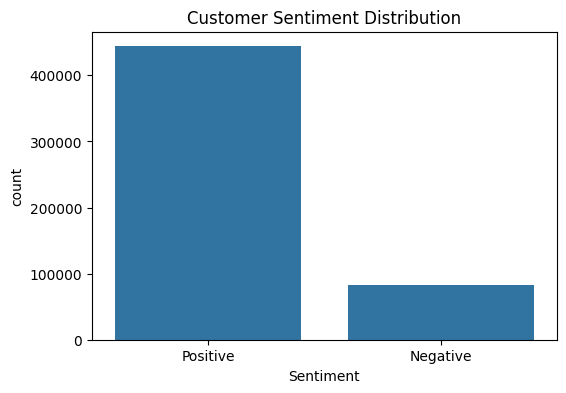

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Customer Sentiment Distribution")
plt.show()

In [15]:
df_sample = df.sample(
    n=10000,
    random_state=42
)

df_sample = df_sample[[
    "Text",
    "Sentiment"
]]

df_sample.dropna(inplace=True)

print(df_sample.shape)

df_sample.head()

(10000, 2)


,Text,Sentiment
443593,This is a very high quality dog food with meat...,Positive
136949,I love this cake mix and the other 3 mixes as ...,Positive
520459,A nice strong brew. I am new to Keurig and hav...,Positive
219515,I just found PB2 and PB2 with chocolate and I ...,Positive
471273,Delightful mint tea as one would expect. Note ...,Positive


In [17]:
X = df_sample["Text"]
y = df_sample["Sentiment"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Train Shape:", X_train_tfidf.shape)
print("Test Shape :", X_test_tfidf.shape)

Train Shape: (8000, 1000)
Test Shape : (2000, 1000)


In [25]:
y_train_nn = y_train.map({
    "Negative":0,
    "Positive":1
})

y_test_nn = y_test.map({
    "Negative":0,
    "Positive":1
})


In [26]:
model = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(1000,)
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        64,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,129 (250.50 KB)

 Trainable params: 64,129 (250.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)



In [29]:
history = model.fit(
    X_train_tfidf,
    y_train_nn,
    validation_split=0.2,
    epochs=5,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8377 - loss: 0.4924 - val_accuracy: 0.8413 - val_loss: 0.4052
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8462 - loss: 0.3702 - val_accuracy: 0.8413 - val_loss: 0.3598
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8573 - loss: 0.3076 - val_accuracy: 0.8650 - val_loss: 0.3073
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8967 - loss: 0.2477 - val_accuracy: 0.8881 - val_loss: 0.2738
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9181 - loss: 0.2130 - val_accuracy: 0.8900 - val_loss: 0.2633


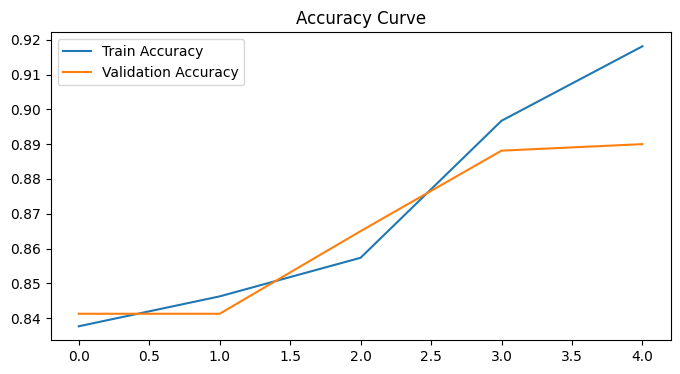

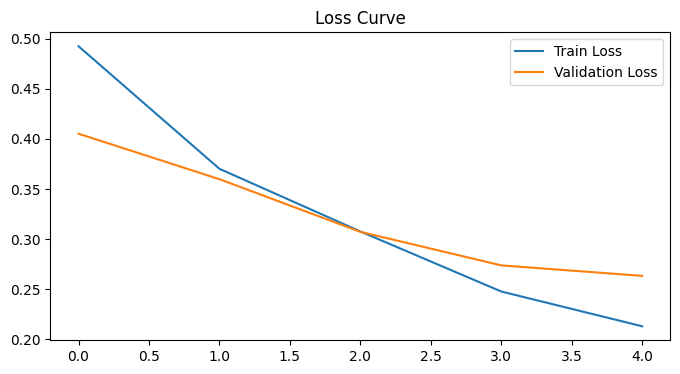

In [30]:
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()


In [31]:
y_pred_prob = model.predict(X_test_tfidf)

y_pred = (
    y_pred_prob > 0.5
).astype(int)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [32]:
print("\nAccuracy:")
print(accuracy_score(
    y_test_nn,
    y_pred
))

print("\nClassification Report:")
print(classification_report(
    y_test_nn,
    y_pred
))

print("\nConfusion Matrix:")
cm = confusion_matrix(
    y_test_nn,
    y_pred
)

print(cm)


Accuracy:
0.889

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.47      0.57       309
           1       0.91      0.97      0.94      1691

    accuracy                           0.89      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.88      0.89      0.88      2000


Confusion Matrix:
[[ 146  163]
 [  59 1632]]


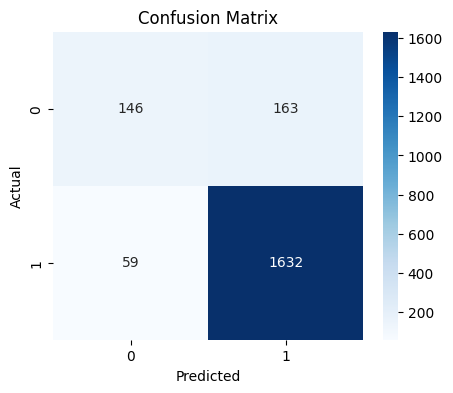

In [33]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
new_review = [
    "This product is excellent and very tasty"
]

new_review_tfidf = tfidf.transform(
    new_review
)

prediction = model.predict(
    new_review_tfidf
)

if prediction[0][0] > 0.5:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Sentiment: Positive
